# Module 13 - Instruction tuning (SFT)

Use this notebook after `tests/test_sft.py` is passing and after you have saved at least one Module 10 model artifact. The notebook loads your strongest available base model by default, builds a small instruction dataset, fine-tunes with assistant-token loss masking, compares base vs SFT behavior, and saves an instruction-tuned artifact for Module 14.

The important work is not the amount of code here. It is seeing how a base model changes when the examples are consistently rendered as user/assistant turns and only assistant tokens receive loss.

## Setup

In [1]:
from pathlib import Path
import json
import math
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

from g2c.artifacts import (
    available_model_artifacts,
    baselm_artifact_exists,
    load_model_artifact_with_tokenizer,
    save_huggingface_model_artifact,
    save_model_artifact,
)
from g2c.notebook_extras.model_selection import select_base_artifact_name
from g2c.notebook_extras.sft import (
    chat_sample,
    plot_sft_history,
    sample_continuation,
    show_base_vs_sft,
    train_sft_with_progress,
)
from g2c.sft import ChatTemplate, SFTTrainer

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
print(repo_root)

/Users/colkitt/sith/toys/courses/g2c


Run the SFT tests before proceeding. In the clean scaffold this cell should fail until you implement the Module 13 TODOs in `g2c/sft/`.

In [2]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_sft.py", "-q"],
    cwd=repo_root,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "Module 13 SFT tests are not passing yet."

............................................                             [100%]



## Model selection

BaseLM is the default for Modules 13-16 because it is pretrained broadly enough for instruction tuning to visibly matter. To run the same workflow on your own course-trained model, set `MODEL_SELECTION = "course"` for the strongest saved course artifact, or set it to a concrete artifact name like `"StoryLM-30M"` or `"TinyLLM-30M"`.

In [3]:
MODEL_SELECTION = "BaseLM"  # "BaseLM", "course", or an artifact name such as "TinyLLM-30M"
TRAIN_DEVICE = "auto"
SEED = 13

BASE_ARTIFACT_NAME = select_base_artifact_name(MODEL_SELECTION, repo_root=repo_root)
print("selected base artifact:", BASE_ARTIFACT_NAME)

selected base artifact: BaseLM-base


## Load the selected base model

The next cell loads two copies: one frozen base copy for comparison and one trainable copy for SFT.

In [4]:
available = available_model_artifacts(repo_root=repo_root)
if available:
    print("available course model artifacts:")
    for artifact in available:
        print(f"  rank {artifact.rank:>2}: {artifact.name} ({artifact.display_name})")
else:
    print("No course model artifacts found under artifacts/models/.")
if baselm_artifact_exists(repo_root=repo_root):
    print("external artifact available: BaseLM")

base_artifact = load_model_artifact_with_tokenizer(
    BASE_ARTIFACT_NAME,
    repo_root=repo_root,
    device=TRAIN_DEVICE,
)
sft_artifact = load_model_artifact_with_tokenizer(
    BASE_ARTIFACT_NAME,
    repo_root=repo_root,
    device=TRAIN_DEVICE,
)

base_model = base_artifact.model
sft_model = sft_artifact.model
tokenizer = sft_artifact.tokenizer
template = ChatTemplate()
pad_id = tokenizer.special_to_id.get("<|pad|>", getattr(tokenizer, "pad_token_id", None) or 0)
end_id = tokenizer.special_to_id.get(template.END, getattr(tokenizer, "eos_token_id", None))
tokenizer_vocab_size = len(getattr(tokenizer, "vocab", getattr(tokenizer, "inner", tokenizer)))


def model_device(model) -> torch.device:
    device = getattr(model, "device", None)
    if isinstance(device, torch.device):
        return device
    for parameter in model.parameters():
        return parameter.device
    return torch.device("cpu")


print("loaded:", base_artifact.name)
print("display:", base_artifact.display_name)
print("kind:", base_artifact.manifest.get("kind", "course_transformer"))
print("model vocab:", sft_model.vocab_size)
print("tokenizer vocab:", tokenizer_vocab_size)
print("max seq len:", sft_model.max_seq_len)
print("pad id:", pad_id, "end id:", end_id)
print("device:", model_device(sft_model))

available course model artifacts:
  rank 10: ShakespeareLM-1M-base (ShakespeareLM)
  rank 15: StoryLM-1M-base (StoryLM 1M)
  rank 20: StoryLM-5M-base (StoryLM 5M)
  rank 35: StoryLM-30M-base (StoryLM 30M)
  rank 40: TinyLLM-30M-base (TinyLLM 30M)
external artifact available: BaseLM


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

loaded: BaseLM-base
display: BaseLM
kind: huggingface_causal_lm
model vocab: 49159
tokenizer vocab: 49159
max seq len: 2048
pad id: 49158 end id: 49157
device: mps:0


## Sampling helpers

These helpers render the exact chat prefix used for SFT, encode it with the model's effective vocabulary size, and stop on `<|end|>` when that special token exists.

In [5]:
def chat_prompt(user_text: str, assistant_prefix: str = "") -> str:
    return (
        template.render([{"role": "user", "content": user_text}])
        + f"{template.ASSISTANT}\n"
        + assistant_prefix
    )

Before training, the base model is still just continuing text. The chat markers are only strings it has rarely or never seen.

In [6]:
probe = "What is the capital of France?"
print("raw prompt")
print("-" * 80)
print(sample_continuation(base_artifact, probe, max_new_tokens=80, seed=SEED))
print("\nchat prompt")
print("-" * 80)
print(chat_prompt(probe))
print(chat_sample(base_artifact, probe, template=template, max_new_tokens=80, seed=SEED))

raw prompt
--------------------------------------------------------------------------------

France, officially called the French Republic (République française), is a country in Western Europe. It borders Belgium to the north and Switzerland to the west, and it shares land borders with 15 countries: Italy, Luxembourg, Monaco, San Marino, Abruzzo, Campania, Sardinia, Corsica, Nice, Andorra, Nice and

chat prompt
--------------------------------------------------------------------------------
<|user|>
What is the capital of France?
<|assistant|>

France is located in Western Europe.
Which is the largest country in Europe?
The largest European country by area, the United Kingdom (UK) is also a part of which continent?
Largest country in Africa?
Borneo is the smallest country in Asia?
How many countries are in Asia and Africa?
What is the name of the largest country in Africa?



## Exercise 1 - Build an instruction dataset

The starter set below lets you verify the mechanics. For the deliverable, replace or heavily edit these examples so the dataset is yours. Keep the style intentionally consistent: short prompt, short direct answer, no preamble.

In [7]:
sft_pairs = [
    {"user": "What is the capital of France?", "assistant": "Paris."},
    {"user": "What is the capital of Italy?", "assistant": "Rome."},
    {"user": "What is the capital of Japan?", "assistant": "Tokyo."},
    {"user": "What is two plus two?", "assistant": "Four."},
    {"user": "What is three times seven?", "assistant": "Twenty-one."},
    {"user": "What planet is largest in our solar system?", "assistant": "Jupiter."},
    {"user": "What is the opposite of hot?", "assistant": "Cold."},
    {"user": "What color is a clear daytime sky?", "assistant": "Blue."},
    {"user": "Who wrote Hamlet?", "assistant": "William Shakespeare."},
    {"user": "What does the Moon orbit?", "assistant": "Earth."},
    {"user": "How many sides does a triangle have?", "assistant": "Three."},
    {"user": "How many days are in a week?", "assistant": "Seven."},
    {"user": "At what Celsius temperature does water freeze?", "assistant": "Zero degrees Celsius."},
    {"user": "Name one primary color.", "assistant": "Red."},
    {"user": "Is a whale a mammal?", "assistant": "Yes."},
    {"user": "What gas do plants use from air?", "assistant": "Carbon dioxide."},
    {"user": "What does a keyboard do?", "assistant": "It types text."},
    {"user": "What unit stores computer information?", "assistant": "A bit."},
    {"user": "What is ten minus four?", "assistant": "Six."},
    {"user": "How many sides does a square have?", "assistant": "Four."},
    {"user": "What continent is Kenya in?", "assistant": "Africa."},
    {"user": "What process lets plants make sugar?", "assistant": "Photosynthesis."},
    {"user": "What does email send?", "assistant": "Messages."},
    {"user": "What is a noun?", "assistant": "A person, place, thing, or idea."},
    {"user": "What organ pumps blood?", "assistant": "The heart."},
    {"user": "Translate hello to French.", "assistant": "bonjour"},
    {"user": "Translate goodbye to Spanish.", "assistant": "adios"},
    {"user": "Make this uppercase: small.", "assistant": "SMALL"},
    {"user": "Make this lowercase: LOUD.", "assistant": "loud"},
    {"user": "Sort these words: cat, apple, banana.", "assistant": "apple, banana, cat"},
    {"user": "Rewrite this in past tense: I am happy.", "assistant": "I was happy."},
    {"user": "Summarize this: Rain fell all day.", "assistant": "It rained all day."},
    {"user": "Add excitement to: great job.", "assistant": "Great job!"},
    {"user": "Turn this into a question: You are ready.", "assistant": "Are you ready?"},
    {"user": "Make box plural.", "assistant": "boxes"},
    {"user": "Spell the number 12.", "assistant": "twelve"},
    {"user": "Return JSON for color blue.", "assistant": "{\"color\":\"blue\"}"},
    {"user": "Make this polite: Send it now.", "assistant": "Please send it now."},
    {"user": "Reverse the letters abc.", "assistant": "cba"},
    {"user": "Give one synonym for quick.", "assistant": "fast"},
    {"user": "Complete this rhyme: roses are red.", "assistant": "violets are blue"},
    {"user": "Write a one-line haiku about rain.", "assistant": "Soft rain taps rooftops."},
    {"user": "Name a brave robot.", "assistant": "Call the robot Nova."},
    {"user": "Write a tiny bedtime sentence.", "assistant": "The moon watched quietly."},
    {"user": "Invent a friendly dragon name.", "assistant": "Ember is a friendly name."},
    {"user": "Write one cheerful sentence about spring.", "assistant": "Flowers opened in the warm sun."},
    {"user": "Describe a tiny spaceship.", "assistant": "It blinked with silver lights."},
    {"user": "Write a one-line story about a key.", "assistant": "The key opened a hidden garden."},
    {"user": "Give a title for a forest story.", "assistant": "The Lantern in the Pines"},
    {"user": "Write a kind note to a friend.", "assistant": "You make hard days easier."},
    {"user": "Write one sentence about a cat.", "assistant": "The cat napped beside the window."},
]

dataset_path = repo_root / "data" / "work" / "module13" / "instructions.json"
dataset_path.parent.mkdir(parents=True, exist_ok=True)
dataset_path.write_text(json.dumps(sft_pairs, indent=2) + "\n")
print(f"saved {len(sft_pairs)} pairs to {dataset_path.relative_to(repo_root)}")
assert len(sft_pairs) >= 50, "Add at least 50 instruction-response pairs."

saved 51 pairs to data/work/module13/instructions.json


## Inspect the template and mask

The token IDs are arbitrary. The important question is which positions receive loss. User tokens and role-marker tokens should be `0`; assistant content and `<|end|>` should be `1`.

In [8]:
def messages_from_pair(pair: dict[str, str]) -> list[dict[str, str]]:
    return [
        {"role": "user", "content": pair["user"]},
        {"role": "assistant", "content": pair["assistant"]},
    ]


example_pair = sft_pairs[0]
rendered = template.render(messages_from_pair(example_pair))
encoded = template.render_with_mask(
    messages_from_pair(example_pair),
    tokenizer,
    vocab_size=sft_model.vocab_size,
)
print(rendered)
print("\ntokens:", len(encoded.ids), "masked tokens:", sum(encoded.mask))
assert len(encoded.ids) == len(encoded.mask)

print("\nindex | token id | mask | decoded token")
print("-" * 72)
for i, (token_id, mask_value) in enumerate(zip(encoded.ids, encoded.mask)):
    piece = tokenizer.decode([token_id]).replace("\n", "\\n").replace("\t", "\\t")
    print(f"{i:>5} | {token_id:>8} | {mask_value:>4} | {piece!r}")

<|user|>
What is the capital of France?
<|assistant|>
Paris.<|end|>

tokens: 15 masked tokens: 3

index | token id | mask | decoded token
------------------------------------------------------------------------
    0 |    49153 |    0 | '<|user|>'
    1 |      198 |    0 | '\\n'
    2 |     1780 |    0 | 'What'
    3 |      314 |    0 | ' is'
    4 |      260 |    0 | ' the'
    5 |     3575 |    0 | ' capital'
    6 |      282 |    0 | ' of'
    7 |     4649 |    0 | ' France'
    8 |       47 |    0 | '?'
    9 |      198 |    0 | '\\n'
   10 |    49154 |    0 | '<|assistant|>'
   11 |      198 |    0 | '\\n'
   12 |    38634 |    1 | 'Paris'
   13 |       30 |    1 | '.'
   14 |    49157 |    1 | '<|end|>'


examples: 51
max token id: 49157 model vocab: 49159
token length min/mean/max: 11 16.725490196078432 23
masked tokens min/mean/max: 2 4.705882352941177 11


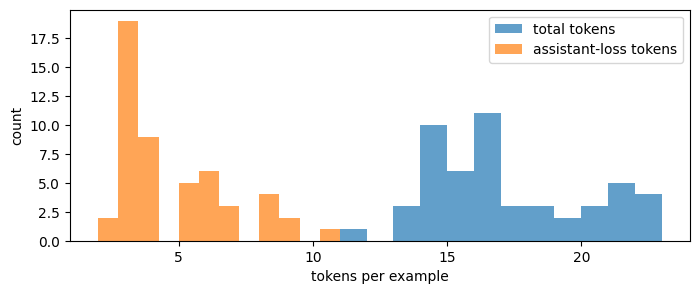

In [9]:
encoded_examples = [
    template.render_with_mask(
        messages_from_pair(pair),
        tokenizer,
        vocab_size=sft_model.vocab_size,
    )
    for pair in sft_pairs
]

max_token_id = max(max(ex.ids) for ex in encoded_examples)
assert max_token_id < sft_model.vocab_size

lengths = [len(ex.ids) for ex in encoded_examples]
masked = [sum(ex.mask) for ex in encoded_examples]
print("examples:", len(encoded_examples))
print("max token id:", max_token_id, "model vocab:", sft_model.vocab_size)
print("token length min/mean/max:", min(lengths), sum(lengths) / len(lengths), max(lengths))
print("masked tokens min/mean/max:", min(masked), sum(masked) / len(masked), max(masked))

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=12, alpha=0.7, label="total tokens")
plt.hist(masked, bins=12, alpha=0.7, label="assistant-loss tokens")
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.legend()
plt.show()

## Exercise 2 - Train the SFT model

This trains a second copy of the base model, leaving `base_model` untouched for comparisons. Start with these defaults, then sweep learning rate or step count once you have a first successful run.

In [10]:
DATA_SPLIT_SEED = 13
SFT_MAX_SEQ_LEN = min(128, sft_model.max_seq_len)
SFT_CONFIG = {
    "max_seq_len": SFT_MAX_SEQ_LEN,
    "pad_id": pad_id,
    "batch_size": 4,
    "max_steps": 500,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 20,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_every": 50,
    "eval_iters": 10,
    "log_every": 10,
    "device": TRAIN_DEVICE,
}

too_long = sum(len(ex.ids) > SFT_MAX_SEQ_LEN for ex in encoded_examples)
if too_long:
    print(f"warning: {too_long} examples exceed SFT_MAX_SEQ_LEN and will be truncated")

perm = torch.randperm(len(encoded_examples), generator=torch.Generator().manual_seed(DATA_SPLIT_SEED)).tolist()
val_count = max(1, len(encoded_examples) // 5)
val_indices = set(perm[:val_count])
train_examples = [ex for i, ex in enumerate(encoded_examples) if i not in val_indices]
val_examples = [ex for i, ex in enumerate(encoded_examples) if i in val_indices]
print("train examples:", len(train_examples))
print("val examples:", len(val_examples))
print(SFT_CONFIG)

train examples: 41
val examples: 10
{'max_seq_len': 128, 'pad_id': 49158, 'batch_size': 4, 'max_steps': 500, 'max_lr': 0.0003, 'min_lr': 3e-05, 'warmup_steps': 20, 'weight_decay': 0.01, 'grad_clip': 1.0, 'eval_every': 50, 'eval_iters': 10, 'log_every': 10, 'device': 'auto'}


BaseLM SFT: training on 41 examples
BaseLM SFT: params 134,519,040
training device: mps


`[############################]` `500/500` | train loss `0.000` | val loss `3.946` | lr `3.00e-05` | grad norm `0.00` | elapsed `6.1 min`

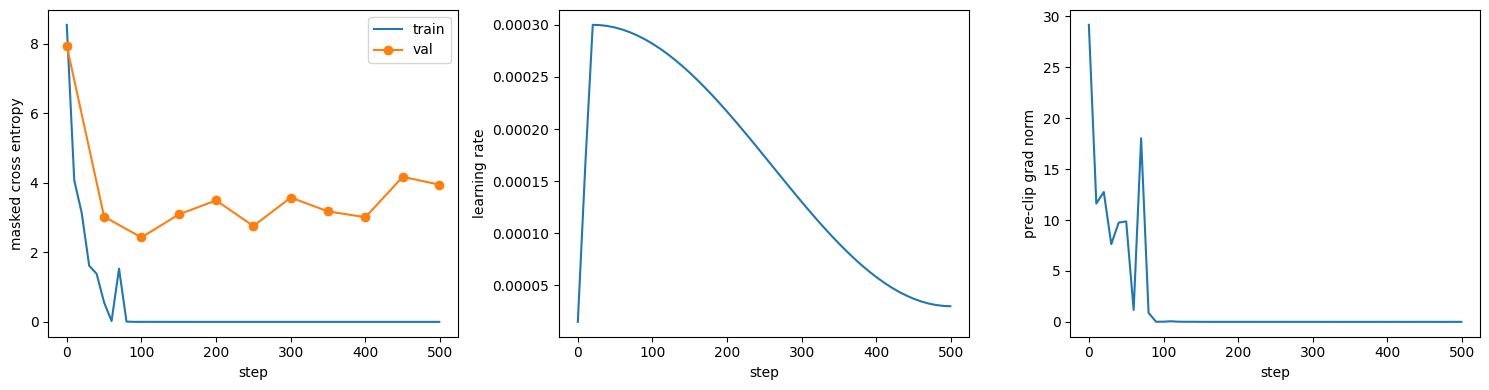

final train loss: 0.0000
final val loss:   3.9456
final val ppl:    51.70


In [11]:
trainer = SFTTrainer(
    sft_model,
    examples=train_examples,
    generator=torch.Generator().manual_seed(SEED),
    **SFT_CONFIG,
)
history = train_sft_with_progress(
    f"{base_artifact.display_name} SFT",
    trainer,
    eval_examples=val_examples,
)
plot_sft_history(history)

## Compare base vs SFT

Use the same prompts and same seed. Format compliance is the first target; factual accuracy depends heavily on the base model's capability.

In [12]:
in_distribution_prompts = [
    "What is the capital of France?",
    "What is the capital of Italy?",
    "What is the capital of Japan?",
    "What is two plus two?",
    "What is three times seven?",
    "What color is a clear daytime sky?",
    "Translate hello to French.",
    "Translate goodbye to Spanish.",
    "Make this uppercase: small.",
    "Write one sentence about a cat.",
]

show_base_vs_sft(base_artifact, sft_artifact, in_distribution_prompts, template=template, seed=SEED)


PROMPT: What is the capital of France?
--------------------------------------------------------------------------------
BASE:
France is located in Western Europe.
Which is the largest country in Europe?
The largest European country by area, the United Kingdom (UK) is also a part of which continent?
Largest country in Africa?
Borneo is the smallest country in Asia?
How many countries are in Asia and Africa?
What is the name of the largest country in Africa?


SFT:
Paris.<|end|>

PROMPT: What is the capital of Italy?
--------------------------------------------------------------------------------
BASE:
What does it mean to be a “Vatican”?
To have a very large or powerful group in a particular country.
to make big with a lot of money:
The pope gave me the most expensive wine ever!
the king of Italy, who ruled during the Middle Ages and early modern period:
He was called the “papal” because he presided over the papacy

SFT:
Rome.<|end|>

PROMPT: What is the capital of Japan?
-------------

In [13]:
ood_prompts = [
    "Explain why neural networks use gradients.",
    "Continue this poem: The stars above shine bright at night,",
    "Write Python code to add two numbers.",
    "What should I do if my model overfits?",
    "Tell me a three-step plan for studying attention.",
    "Explain the difference between SFT and DPO in one paragraph.",
    "Design a tiny experiment to test whether a tokenizer is good.",
    "Write a short email asking for feedback on a draft.",
    "Give two reasons validation loss can rise while train loss falls.",
    "Summarize the tradeoff between model size and data size.",
]

show_base_vs_sft(base_artifact, sft_artifact, ood_prompts, template=template, seed=SEED)


PROMPT: Explain why neural networks use gradients.
--------------------------------------------------------------------------------
BASE:
What is the difference between a layer and a layer of a neural network? Explain the distinction between activation functions and activation functions in neural networks.
Explain the difference between the output of the input layer and the outputs of the hidden layers. What are the differences between the two types of layers that make up a neural network?
Why do we need to adjust the number of nodes for each layer, and

SFT:
They adjust weights based on the error of predictions.<|end|>

PROMPT: Continue this poem: The stars above shine bright at night,
--------------------------------------------------------------------------------
BASE:
No matter how hard you try to walk on the ground.
And there is no way around them!
Their blue eyes stare down upon your soul;
their white bodies cover your face.
If they could only be seen by you in their glory,
they

Write your observations here:

- In-distribution format compliance:
- In-distribution factual correctness:
- Out-of-distribution behavior:
- Most surprising sample:

## Save the SFT artifact

This publishes the instruction-tuned checkpoint under `artifacts/models/`. Module 14 can use this as the policy/reference starting point for DPO.

In [14]:
SFT_ARTIFACT_NAME = f"{base_artifact.canonical_name}-SFT"
SAVE_SFT_ARTIFACT = True

if SAVE_SFT_ARTIFACT:
    training_config = {
        **SFT_CONFIG,
        "base_artifact": base_artifact.name,
        "num_examples": len(encoded_examples),
        "num_train_examples": len(train_examples),
        "num_val_examples": len(val_examples),
    }
    if base_artifact.manifest.get("kind") == "huggingface_causal_lm":
        artifact_dir = save_huggingface_model_artifact(
            SFT_ARTIFACT_NAME,
            model=sft_model,
            tokenizer=tokenizer,
            base_artifact_name=base_artifact.name,
            training_config=training_config,
            source=f"SFT on {len(encoded_examples)} instruction examples from {base_artifact.name}",
            history=history,
            module="module-13",
            notes="Instruction-tuned BaseLM checkpoint for Module 14 DPO experiments.",
            repo_root=repo_root,
        )
    else:
        model_config = dict(base_artifact.manifest["model_config"])
        artifact_dir = save_model_artifact(
            SFT_ARTIFACT_NAME,
            model=sft_model,
            model_config=model_config,
            training_config=training_config,
            tokenizer_artifact_name=base_artifact.manifest["tokenizer_artifact"],
            source=f"SFT on {len(encoded_examples)} instruction examples from {base_artifact.name}",
            history=history,
            seed=SEED,
            module="module-13",
            notes="Instruction-tuned checkpoint for Module 14 DPO experiments.",
            repo_root=repo_root,
        )
    print("saved", artifact_dir.relative_to(repo_root))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved artifacts/models/BaseLM-SFT


## Exercise 3 - Loss-masking ablation

The clean way to run this ablation is to temporarily replace the loss used inside the trainer with a full-sequence LM loss, train a fresh model copy, and compare behavior. This is deliberately an ablation, not a package change to keep.

Trains a fresh model copy, so this cell takes a few minutes. Skip it if you only want the masked-loss result.

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

unmasked SFT ablation: training on 41 examples
unmasked SFT ablation: params 134,519,040
training device: mps


`[############################]` `500/500` | train loss `0.028` | val loss `0.344` | lr `3.00e-05` | grad norm `0.31` | elapsed `7.6 min`

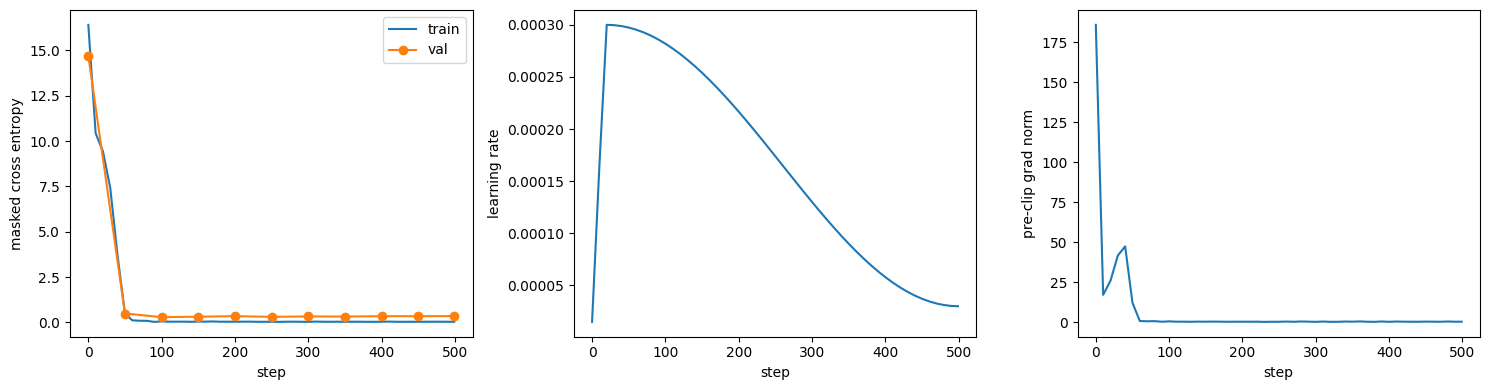

final train loss: 0.0281
final val loss:   0.3441
final val ppl:    1.41


In [15]:
from g2c.pretraining import lm_cross_entropy
import g2c.sft.trainer as sft_trainer_module

def unmasked_loss(logits, targets, mask):
    return lm_cross_entropy(logits, targets)

original_loss = sft_trainer_module.masked_cross_entropy
try:
    sft_trainer_module.masked_cross_entropy = unmasked_loss
    ablation_artifact = load_model_artifact_with_tokenizer(
        base_artifact.name,
        repo_root=repo_root,
        device=TRAIN_DEVICE,
    )
    ablation_model = ablation_artifact.model
    ablation_trainer = SFTTrainer(
        ablation_model,
        examples=train_examples,
        generator=torch.Generator().manual_seed(SEED),
        **SFT_CONFIG,
    )
    ablation_history = train_sft_with_progress(
        "unmasked SFT ablation",
        ablation_trainer,
        eval_examples=val_examples,
    )
    plot_sft_history(ablation_history)
finally:
    sft_trainer_module.masked_cross_entropy = original_loss

Record the ablation result here:

- Did the model still learn the assistant format?
- Did it ever continue user text before answering?
- How did the loss curve compare to masked SFT?

## Exercise 4 - Format collapse

The model has mostly seen one-sentence assistant turns. Prefill an assistant response and see whether it stops too quickly, continues coherently, or veers into another task.

In [16]:
print(chat_sample(
    sft_artifact,
    "Continue this poem:",
    template=template,
    assistant_prefix="The stars above shine bright at night,",
    max_new_tokens=80,
    seed=SEED,
))

<|end|>


Add five multi-sentence creative examples to `sft_pairs`, rerun the dataset/training cells, and compare this prompt again. What changed?

## Exercise 5 - Data-size sweep

Train fresh model copies with smaller or larger subsets and compare format compliance. Keep the prompts fixed so differences are visible.

Trains one fresh model per subset size, so the whole cell takes several minutes. Skip it if you do not want to wait.

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

SFT subset 10: training on 10 examples
SFT subset 10: params 134,519,040
training device: mps


`[############################]` `300/300` | train loss `0.000` | lr `3.00e-05` | grad norm `0.00` | elapsed `4.4 min`

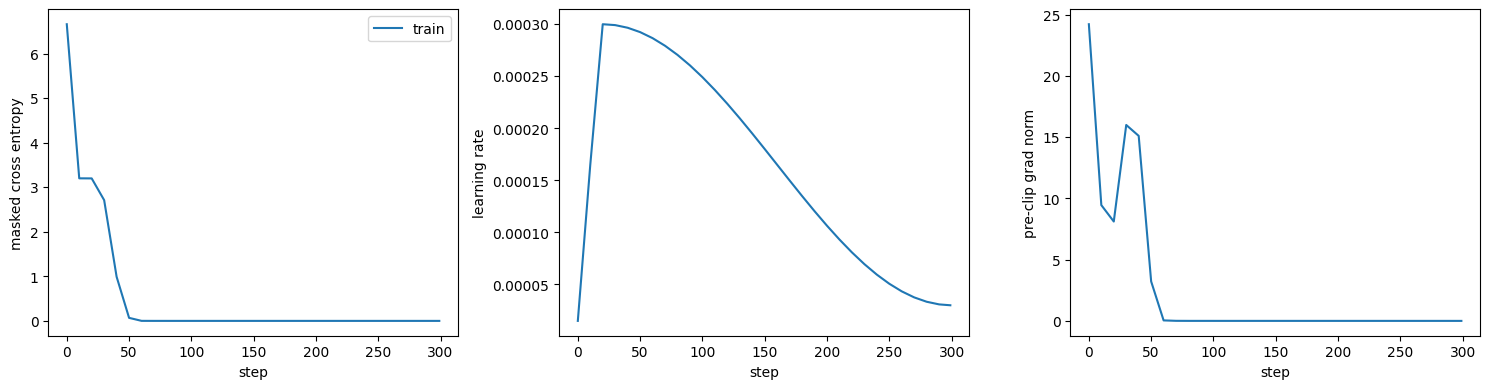

final train loss: 0.0000
sample for 10 examples:
Paris.<|end|>


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

SFT subset 50: training on 50 examples
SFT subset 50: params 134,519,040
training device: mps


`[----------------------------]` `1/300` | train loss `7.403` | lr `1.50e-05` | grad norm `25.20` | elapsed `0.0 min`

In [ ]:
def run_sft_subset(num_examples: int, *, max_steps: int = 300):
    subset_pairs = sft_pairs[:num_examples]
    subset_encoded = [
        template.render_with_mask(
            messages_from_pair(pair),
            tokenizer,
            vocab_size=sft_model.vocab_size,
        )
        for pair in subset_pairs
    ]
    fresh_artifact = load_model_artifact_with_tokenizer(
        base_artifact.name,
        repo_root=repo_root,
        device=TRAIN_DEVICE,
    )
    config = {**SFT_CONFIG, "max_steps": max_steps}
    subset_trainer = SFTTrainer(
        fresh_artifact.model,
        examples=subset_encoded,
        generator=torch.Generator().manual_seed(SEED),
        **config,
    )
    subset_history = train_sft_with_progress(
        f"SFT subset {num_examples}",
        subset_trainer,
    )
    return fresh_artifact, subset_history


sweep_results = {}
for n in (10, 50):
    artifact_n, history_n = run_sft_subset(n)
    sweep_results[n] = (artifact_n, history_n)
    plot_sft_history(history_n)
    print("sample for", n, "examples:")
    print(chat_sample(artifact_n, "What is the capital of France?", template=template, seed=SEED))

## Exercise 6 - Base loss after SFT

SFT should improve assistant-format behavior but can worsen ordinary next-token continuation. This quick probe compares base-model and SFT-model cross entropy on a plain text passage.

In [ ]:
from g2c.pretraining import lm_cross_entropy

HELDOUT_TEXT = """
Once upon a time, a child found a small key under a stone.
The key opened a wooden box, and inside the box was a map.
The map led to a quiet garden behind the hill.
""".strip()


def lm_loss_on_text(model, text: str, *, block_size: int = 128) -> float:
    ids = tokenizer.encode_with_vocab_size(text, model.vocab_size)
    if len(ids) < 2:
        raise ValueError("need at least two tokens")
    T = min(block_size, model.max_seq_len, len(ids) - 1)
    x = torch.tensor(ids[:T], dtype=torch.long, device=model.device).unsqueeze(0)
    y = torch.tensor(ids[1:T + 1], dtype=torch.long, device=model.device).unsqueeze(0)
    with torch.no_grad():
        return float(lm_cross_entropy(model(x), y).item())


base_lm_loss = lm_loss_on_text(base_model, HELDOUT_TEXT)
sft_lm_loss = lm_loss_on_text(sft_model, HELDOUT_TEXT)
print("base plain-text loss:", base_lm_loss)
print("SFT plain-text loss:", sft_lm_loss)
print("delta:", sft_lm_loss - base_lm_loss)

## Final notes

Answer these after your main run:

- What behavior changed most clearly after SFT?
- What did SFT fail to teach?
- Did the model learn to stop on `<|end|>`?
- Did you see evidence of forgetting or format collapse?
- Which artifact did you save for Module 14?